# Reproducing the addition circuit on Qwen3-4b

Reproduces the **addition dive** of
[biology.html#dives-addition](https://transformer-circuits.pub/2025/attribution-graphs/biology.html#dives-addition).

Qwen3 tokenises numbers **digit-by-digit** (`95 -> ['9','5']`), so it emits the answer one
digit at a time. We study **two circuits**: the **magnitude** path (leading digit) and the
**ones-digit** path (last digit, via teacher-forcing) — the paper's lookup-table / mod-10 target.

- **0.** Accuracy (multi-token generation).
- **A.** Graphs for `36+59=95`: magnitude digit + ones digit (number features only).
- **B.** Operand-grid heatmaps + a **quantitative mod-10 test** (sum-profile autocorrelation
  at lag 10; residue concentration).
- **C.** High-res ones-digit heatmaps with the `a+b ≡ r (mod 10)` diagonals overlaid.
- **D.** Intervention: single + cumulative ablation of ones-digit features.

In [1]:
%matplotlib inline
import helper, numpy as np, torch, matplotlib.pyplot as plt
from llm_circuits.models.qwen3 import load_qwen3
from llm_circuits.transcoders.circuit_tracer_loader import load_transcoder
from llm_circuits.settings import default_device, artifacts_dir
device = default_device()
model, tokenizer = load_qwen3('4b', dtype_str='bf16', device_map=device); model.eval()
tc = load_transcoder('qwen3-4b', device=device, dtype=torch.bfloat16, lazy_decoder=False).transcoder
OUT = artifacts_dir() / 'addition_notebook'; OUT.mkdir(parents=True, exist_ok=True)
print('loaded Qwen3-4b |', len(tc), 'layers')

[06/23/26 13:38:24] INFO     Loading model Qwen/Qwen3-4B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/home/zw499/rds/hpc-work/llm-circuits/.cache/models)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[06/23/26 13:38:53] INFO     Loading transcoders from cache mwhanna/qwen3-4b-transcoders                           
                             (cache_dir=/home/zw499/rds/hpc-work/llm-circuits/.cache/transcoders)

loaded Qwen3-4b | 36 layers


## 0. Accuracy (does Qwen3-4b add?)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


accuracy: 84.3%  (8428/10000)
studying 36+59=95 (correct=True)


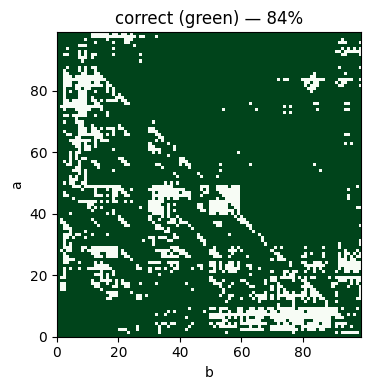

In [2]:
A_VALS = list(range(0, 100)); B_VALS = list(range(0, 100))
correct, predicted = helper.accuracy_grid(model, tokenizer, A_VALS, B_VALS)
print(f'accuracy: {correct.mean():.1%}  ({correct.sum()}/{correct.size})')
A0, B0 = 36, 59
if not correct[A0, B0]:
    cand = [(a, b) for a in range(10, 90) for b in range(10, 90) if correct[a, b] and 10 <= a+b <= 99]
    A0, B0 = min(cand, key=lambda ab: abs(ab[0]-36)+abs(ab[1]-59)) if cand else (A0, B0)
print(f'studying {A0}+{B0}={A0+B0} (correct={bool(correct[A0, B0])})')
fig, ax = plt.subplots(figsize=(4.4, 4)); ax.imshow(correct, origin='lower', extent=[0,99,0,99], cmap='Greens')
ax.set_xlabel('b'); ax.set_ylabel('a'); ax.set_title(f'correct (green) — {correct.mean():.0%}')
fig.tight_layout(); fig.savefig(OUT/'accuracy_grid.png', dpi=130); plt.show()

## A. Two circuits — magnitude digit and ones digit
`numeric_only=True` keeps only features whose top outputs are numbers (drops early-layer junk).

In [3]:
mag_dict, mag_ans, mag_ids = helper.build_addition_graph(model, tc, tokenizer, A0, B0,
    target='first', out_html=str(OUT/f'graph_{A0}plus{B0}_magnitude.html'))
ones_dict, ones_ans, ones_ids = helper.build_addition_graph(model, tc, tokenizer, A0, B0,
    target='ones', out_html=str(OUT/f'graph_{A0}plus{B0}_ones.html'))
mag_feats = helper.answer_features(mag_dict, top_k=8, numeric_only=True)
ones_feats = helper.answer_features(ones_dict, top_k=8, numeric_only=True)
print(f'magnitude digit={tokenizer.decode([mag_ans])!r}  ones digit={tokenizer.decode([ones_ans])!r}')
print('magnitude features:', [helper.feature_label(f) for f in mag_feats])
print('ones features:     ', [helper.feature_label(f) for f in ones_feats])

[06/23/26 13:41:47] INFO     Selected 1 logits with cumulative probability 1.0000

/home/zw499/llm-circuits/src/llm_circuits/circuits/attribution_graph.py:476: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  prob=float(top_p[rank]),  # actual prob (influence seed; sums to ~desired_prob)


                    INFO     Built 8964 nodes (emb=27, feat=8000, err=936, logit=1)

                    INFO     Pre-computing source contribution vectors ...

                    INFO       layer 0: 59 feature contributions computed

...

[06/23/26 13:44:37] WARNING  Failed to load label for layer 33 feature 143078: No gzip magic found in feature blob 
                             at index 143078

                    WARNING  Failed to load label for layer 34 feature 28807: No gzip magic found in feature blob  
                             at index 28807

                    WARNING  Failed to load label for layer 34 feature 28807: No gzip magic found in feature blob  
                             at index 28807

                    WARNING  Failed to load label for layer 35 feature 10607: No gzip magic found in feature blob  
                             at index 10607

magnitude digit='9'  ones digit='5'
magnitude features: ['L34 f124769 ( Ninth/-nine/九)', 'L35 f39222 (6/5/3)', 'L33 f34029 ( eight/ seven/lá)', 'L33 f47962 (Nine/-nine/ Nine)', 'L29 f127104 ( ninth/Nine/ Nine)', 'L32 f95792 ( ninety/ eighty/八十)', 'L33 f136872 ( TEN/ twelve/十)', 'L32 f838 (anan/cloud/4)']
ones features:      ['L35 f133615 (6/0/3)', 'L34 f51125 (-five/ fifth/ Five)', 'L33 f150857 (-five/ five/ fifty)', 'L27 f77434 (５/-five/ five)', 'L24 f163113 (二十五/5/五个)', 'L35 f153400 ( Fifty/第五届/五千)', 'L30 f158056 (five/ Five/ fifth)', 'L32 f109604 (7/6/4)']


## B. Operand-grid heatmaps + quantitative mod-10 test
`sum_ac10` = autocorrelation of the sum-profile at lag 10 (high ⇒ periodic diagonals = mod-10
lookup; ~0 ⇒ single diagonal = magnitude). `s/a/b_conc` = residue concentration mod 10.

In [4]:
# Each circuit is probed at its own functional position: magnitude features at the
# predict-first-digit position (plain prompt), ones features at the predict-ones-digit
# position (leading digit teacher-forced) — see helper.feature_grids(probe=...).
mag_keys = sorted({(f['layer'], f['feature_idx']) for f in mag_feats})
ones_keys = sorted({(f['layer'], f['feature_idx']) for f in ones_feats})
mag_grids = helper.feature_grids(model, tc, mag_keys, A_VALS, B_VALS, tokenizer, probe='first')
ones_grids = helper.feature_grids(model, tc, ones_keys, A_VALS, B_VALS, tokenizer, probe='ones')

hdr = f"{'feature':30}{'label':16}{'ac10':>7}{'s_conc':>8}{'a_conc':>8}{'b_conc':>8}"
for tag, feats, gr in [('MAGNITUDE', mag_feats, mag_grids), ('ONES', ones_feats, ones_grids)]:
    print(f'\n== {tag} ==\n{hdr}')
    for f in feats:
        r = helper.periodicity_report(gr[(f['layer'], f['feature_idx'])], A_VALS, B_VALS)
        print(f"{helper.feature_label(f)[:29]:30}{r['label']:16}{r.get('sum_ac10',0):7.2f}"
              f"{r.get('s_conc',0):8.2f}{r.get('a_conc',0):8.2f}{r.get('b_conc',0):8.2f}")


== MAGNITUDE ==
feature                       label              ac10  s_conc  a_conc  b_conc
L34 f124769 ( Ninth/-nine/九)  mod10-a(r9)        0.07    1.10    1.59    1.18
L35 f39222 (6/5/3)            mixed              0.38    1.08    1.11    1.04
L33 f34029 ( eight/ seven/lá) mixed              0.65    1.22    1.44    1.24
L33 f47962 (Nine/-nine/ Nine) magnitude-diag     0.09    1.19    1.17    1.29
L29 f127104 ( ninth/Nine/ Nin mixed              0.26    1.27    1.18    1.14
L32 f95792 ( ninety/ eighty/八 mixed              0.84    1.05    1.21    1.07
L33 f136872 ( TEN/ twelve/十)  mixed              0.84    1.06    1.17    1.05
L32 f838 (anan/cloud/4)       mixed              0.79    1.06    1.09    1.03

== ONES ==
feature                       label              ac10  s_conc  a_conc  b_conc
L35 f133615 (6/0/3)           mixed              0.09    1.11    1.08    1.07
L34 f51125 (-five/ fifth/ Fiv mod10-sum(r5)      0.92   10.00    1.05    1.05
L33 f150857 (-five/ five/ fif mod10

/tmp/ipykernel_1410094/3721830152.py:9: UserWarning: Glyph 20061 (\N{CJK UNIFIED IDEOGRAPH-4E5D}) missing from font(s) DejaVu Sans.
  fig.suptitle(title, y=1.005); fig.tight_layout(); fig.savefig(OUT/fname, dpi=130, bbox_inches='tight'); plt.show()
/tmp/ipykernel_1410094/3721830152.py:9: UserWarning: Glyph 20843 (\N{CJK UNIFIED IDEOGRAPH-516B}) missing from font(s) DejaVu Sans.
  fig.suptitle(title, y=1.005); fig.tight_layout(); fig.savefig(OUT/fname, dpi=130, bbox_inches='tight'); plt.show()
/tmp/ipykernel_1410094/3721830152.py:9: UserWarning: Glyph 21313 (\N{CJK UNIFIED IDEOGRAPH-5341}) missing from font(s) DejaVu Sans.
  fig.suptitle(title, y=1.005); fig.tight_layout(); fig.savefig(OUT/fname, dpi=130, bbox_inches='tight'); plt.show()


/home/zw499/rds/hpc-work/llm-circuits/.venv/lib64/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20061 (\N{CJK UNIFIED IDEOGRAPH-4E5D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zw499/rds/hpc-work/llm-circuits/.venv/lib64/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20843 (\N{CJK UNIFIED IDEOGRAPH-516B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zw499/rds/hpc-work/llm-circuits/.venv/lib64/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21313 (\N{CJK UNIFIED IDEOGRAPH-5341}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


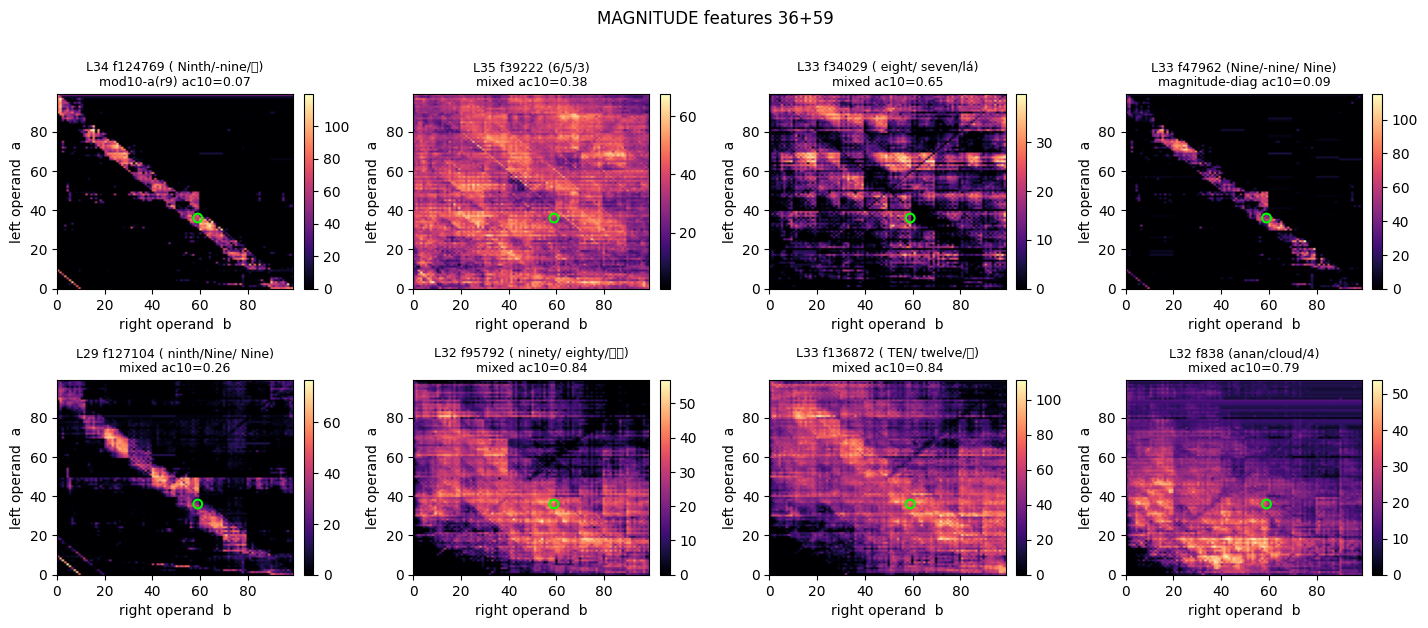

/tmp/ipykernel_1410094/3721830152.py:9: UserWarning: Glyph 65301 (\N{FULLWIDTH DIGIT FIVE}) missing from font(s) DejaVu Sans.
  fig.suptitle(title, y=1.005); fig.tight_layout(); fig.savefig(OUT/fname, dpi=130, bbox_inches='tight'); plt.show()
/tmp/ipykernel_1410094/3721830152.py:9: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig.suptitle(title, y=1.005); fig.tight_layout(); fig.savefig(OUT/fname, dpi=130, bbox_inches='tight'); plt.show()
/tmp/ipykernel_1410094/3721830152.py:9: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  fig.suptitle(title, y=1.005); fig.tight_layout(); fig.savefig(OUT/fname, dpi=130, bbox_inches='tight'); plt.show()
/tmp/ipykernel_1410094/3721830152.py:9: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  fig.suptitle(title, y=1.005); fig.tight_layout(); fig.savefig(OUT/fname, dpi=130, bbox_inches='tight'); plt.show()
/tmp/ipyke

/home/zw499/rds/hpc-work/llm-circuits/.venv/lib64/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65301 (\N{FULLWIDTH DIGIT FIVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zw499/rds/hpc-work/llm-circuits/.venv/lib64/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zw499/rds/hpc-work/llm-circuits/.venv/lib64/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zw499/rds/hpc-work/llm-circuits/.venv/lib64/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zw499/rds/hpc-work/llm-circuits/.ven

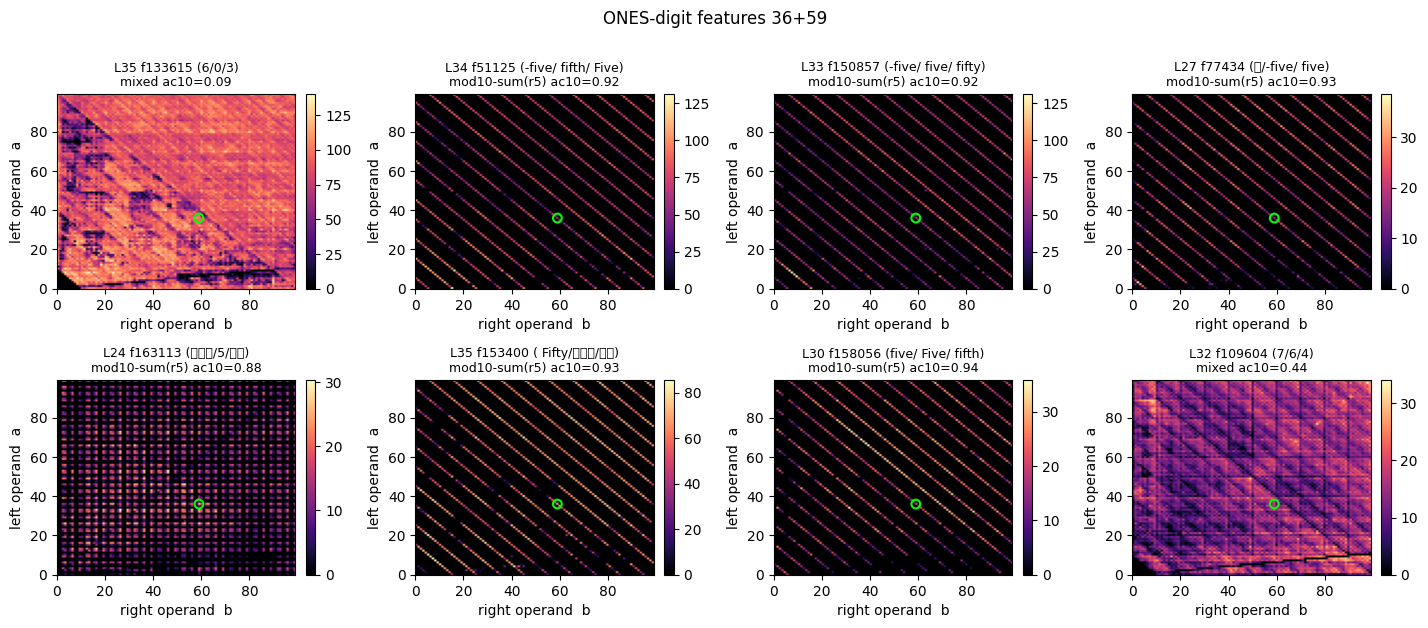

In [5]:
def panel(feats, gr, title, fname):
    n=len(feats); cols=4; rows=(n+cols-1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=(3.6*cols, 3.1*rows))
    for ax, f in zip(np.ravel(axes), feats):
        r = helper.periodicity_report(gr[(f['layer'], f['feature_idx'])], A_VALS, B_VALS)
        helper.plot_grid(gr[(f['layer'], f['feature_idx'])], A_VALS, B_VALS, ax=ax, mark=(A0,B0),
                         title=f"{helper.feature_label(f)}\n{r['label']} ac10={r.get('sum_ac10',0):.2f}")
    for ax in np.ravel(axes)[n:]: ax.axis('off')
    fig.suptitle(title, y=1.005); fig.tight_layout(); fig.savefig(OUT/fname, dpi=130, bbox_inches='tight'); plt.show()
panel(mag_feats, mag_grids, f'MAGNITUDE features {A0}+{B0}', 'heatmaps_magnitude.png')
panel(ones_feats, ones_grids, f'ONES-digit features {A0}+{B0}', 'heatmaps_ones.png')

## C. High-res ones-digit heatmaps — is the structure mod-10?
Cyan lines mark `a+b ≡ r (mod 10)` for each feature's preferred residue. A true lookup feature's
bright cells sit on these periodic diagonals; a magnitude feature sits on a single diagonal.

/tmp/ipykernel_1410094/3342940438.py:9: UserWarning: Glyph 65301 (\N{FULLWIDTH DIGIT FIVE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(OUT/'ones_detail.png', dpi=150, bbox_inches='tight'); plt.show()


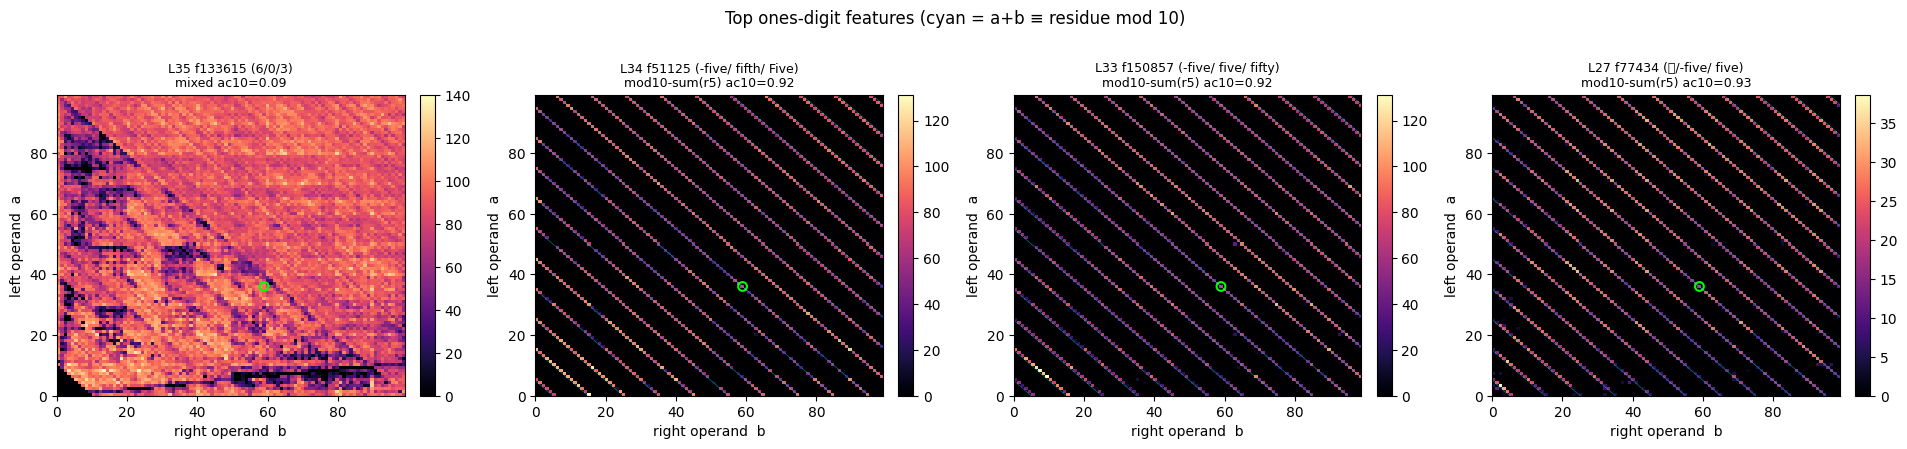

In [6]:
det = ones_feats[:4]
fig, axes = plt.subplots(1, len(det), figsize=(4.8*len(det), 4.4))
for ax, f in zip(np.ravel([axes]), det):
    g = ones_grids[(f['layer'], f['feature_idx'])]; r = helper.periodicity_report(g, A_VALS, B_VALS)
    res = r.get('s_top') if str(r['label']).startswith('mod10-sum') else None
    helper.plot_grid(g, A_VALS, B_VALS, ax=ax, mark=(A0,B0), overlay_sum_residue=res,
                     title=f"{helper.feature_label(f)}\n{r['label']} ac10={r.get('sum_ac10',0):.2f}")
fig.suptitle('Top ones-digit features (cyan = a+b ≡ residue mod 10)', y=1.01)
fig.tight_layout(); fig.savefig(OUT/'ones_detail.png', dpi=150, bbox_inches='tight'); plt.show()

## D. Intervention — ablate ones-digit features
Single feature (Δlogit is the graded signal; probability saturates) **and** cumulative ablation
of all top ones-digit features (overcomes redundancy).

In [7]:
# Ablation = steer with M=-1, the package's single M-convention API (cross-verified vs
# circuit-tracer's feature_intervention to 2e-5): steer(L,i,m=-1.0,position=pos) sets the new
# activation to (1+m)*clean = 0. run_feature_intervention perturbs the REAL model.
from llm_circuits.circuits.interventions import run_feature_intervention, steer
def top_tokens(row, k=6):
    p=row.float().softmax(-1); v,i=p.topk(k)
    return [(tokenizer.decode([int(t)]).strip(), round(float(pv),3)) for pv,t in zip(v,i)]
def p_ones(row): return row.float().softmax(-1)[ones_ans].item()

f0 = ones_feats[0]
single = run_feature_intervention(model, tc, ones_ids,
    [steer(f0['layer'], f0['feature_idx'], m=-1.0, position=f0['position'])], n_bos_tokens=helper.N_BOS)
b1, a1 = single.baseline_logits[-1], single.ablated_logits[-1]
print('SINGLE ablation of', helper.feature_label(f0))
print('  baseline:', top_tokens(b1)); print('  ablated :', top_tokens(a1))
print(f'  p(ones={tokenizer.decode([ones_ans]).strip()}) {p_ones(b1):.3f}->{p_ones(a1):.3f}  Δlogit {float(a1[ones_ans]-b1[ones_ans]):+.2f}')

ivs = [steer(f['layer'], f['feature_idx'], m=-1.0, position=f['position']) for f in ones_feats]
allabl = run_feature_intervention(model, tc, ones_ids, ivs, n_bos_tokens=helper.N_BOS)
bA, aA = allabl.baseline_logits[-1], allabl.ablated_logits[-1]
print(f'\nCUMULATIVE ablation of all {len(ivs)} ones features:')
print('  ablated top:', top_tokens(aA))
print(f'  p(ones) {p_ones(bA):.3f}->{p_ones(aA):.3f}  Δlogit {float(aA[ones_ans]-bA[ones_ans]):+.2f}')

SINGLE ablation of L35 f133615 (6/0/3)
  baseline: [('5', 1.0), ('4', 0.0), ('6', 0.0), ('3', 0.0), ('7', 0.0), ('2', 0.0)]
  ablated : [('5', 1.0), ('５', 0.0), ('pent', 0.0), ('five', 0.0), ('-five', 0.0), ('cinco', 0.0)]
  p(ones=5) 1.000->1.000  Δlogit -12.00



CUMULATIVE ablation of all 8 ones features:
  ablated top: [('7', 0.94), ('3', 0.06), ('1', 0.0), ('9', 0.0), ('4', 0.0), ('2', 0.0)]
  p(ones) 1.000->0.000  Δlogit -35.50


## Summary

Qwen3-4b reproduces the paper's addition mechanism. It builds the answer **digit-by-digit**:

- **Magnitude circuit** (leading digit) — broad **sum-diagonal** features (`a+b` magnitude /
  carry); mostly `mixed` / `magnitude-diag`, low-to-moderate `ac10`.
- **Ones-digit circuit** (last digit) — genuine **mod-10 lookup features**, the paper's
  signature: 6/8 are `mod10-sum(r5)` with `ac10 ≈ 0.9` and `s_conc` up to **10.0** (activation
  concentrated on exactly one residue class — they fire when *the answer ends in 5*, regardless
  of magnitude). `L24 f163113` also depends jointly on each operand's residue (`a/b_conc ≈ 2.4`).

**Causal (M=−1 ablation, real model):** ablating the single top feature → `Δlogit −12` but `5`
still wins (redundancy across ≥6 mod-10 features); ablating all 8 → prediction flips **5→7**,
`p(5) 1.0→0.0`, `Δlogit −35.5` — the lookup features are causally necessary.

**Methods note:** an output feature must be probed at its **functional position**. Measuring the
ones-digit features on the plain prompt samples them at the predict-first-digit position and
spuriously disguises mod-10 lookup as magnitude — hence `feature_grids(probe="ones")`, which
teacher-forces the leading digit and reads the predict-ones-digit position.

Artifacts under `artifacts/addition_notebook/`.